# 05 — Risco de violação de OLA

Classificador por incidente: dada a informação disponível **no instante da abertura**, qual a
probabilidade de aquele chamado estourar o prazo de OLA da sua prioridade?

Três dificuldades reais, tratadas explicitamente:

1. **Classe rara** — ~1% dos elegíveis violam.
2. **Vazamento óbvio à espreita** — duração, data de resolução e código de fechamento descrevem
   o desfecho e precisam ficar fora.
3. **Escala da probabilidade** — treinar com peso de classe distorce a saída; sem calibração o
   número não pode ser chamado de probabilidade.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
RAIZ = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from ml.src import config, dataset, explain, features, metrics, models_zoo, registry, selecao, splits, train
print('Banco:', config.BANCO, '| existe:', config.BANCO.exists())

Banco: C:\Users\Usuario\Downloads\CP\sentinel_ops\db.sqlite3 | existe: True


In [2]:
base = train.preparar_base(verbose=True)
X, y, identificacao = features.features_incidentes(base['incidentes'], base['painel'])
print(f'Incidentes elegíveis: {len(X):,}')
print(f'Violações           : {int(y.sum()):,}  ({y.mean() * 100:.2f}%)')
print(f'Features            : {X.shape[1]}')
X.head(3)

Regime operacional detectado a partir de 2025-01-13 (120,670 incidentes, 55 entidades).
Matriz de features: 122,507 linhas × 85 features.


Incidentes elegíveis: 24,514
Violações           : 231  (0.94%)
Features            : 36


,prioridade,sla_minutos,hora,minuto_do_dia,dow,dia_mes,mes,fim_de_semana,feriado,fora_horario,aberto_manual,tem_produto,tem_item_config,tem_pai,taxa_violacao_equipe,taxa_violacao_produto,taxa_violacao_categoria,taxa_violacao_familia,taxa_violacao_item,carga_equipe_1h,carga_equipe_24h,volume_ci_7d,volume_produto_24h,equipe_media_7,equipe_media_28,equipe_razao_7_28,equipe_p2_media_7,equipe_share_criticos_7,equipe_taxa_violacao_media_28,equipe_violacoes_media_28,equipe_mttr_medio_media_7,equipe_delta_mttr,produto_media_7,produto_razao_7_28,produto_taxa_violacao_media_28,produto_share_criticos_7
0,3.0,720.0,1.0,82.0,0.0,13.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,240.0,4.0,279.0,0.0,13.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,720.0,5.0,312.0,0.0,13.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## O que o modelo vê — e o que não vê

As features cobrem atributos do chamado, calendário, carga do momento e histórico anterior da
entidade. Todas as taxas históricas são **expandidas e deslocadas**: a linha N enxerga as N−1
anteriores daquela equipe, nunca a si mesma.

In [3]:
campos_proibidos = ['duracao_seg', 'resolvido_em', 'encerrado_em', 'status',
                    'cod_fechamento', 'solucao', 'kpi_violado', 'mttr_min']
vazamentos = [c for c in X.columns if any(p in c for p in campos_proibidos)]
print('Campos de desfecho presentes nas features:', vazamentos or 'nenhum')

grupos = {
    'atributos do chamado': ['prioridade', 'sla_minutos', 'aberto_manual', 'tem_produto', 'tem_item_config'],
    'calendário': ['hora', 'minuto_do_dia', 'dow', 'dia_mes', 'mes', 'fim_de_semana', 'feriado', 'fora_horario'],
    'histórico da entidade': [c for c in X.columns if c.startswith('taxa_violacao_')],
    'carga no momento': [c for c in X.columns if c.startswith(('carga_', 'volume_'))],
    'contexto do dia anterior': [c for c in X.columns if c.startswith(('equipe_', 'produto_'))],
}
for nome, itens in grupos.items():
    print(f'{nome:>28}: {len(itens):>2}  {", ".join(itens[:4])}...')

Campos de desfecho presentes nas features: nenhum
        atributos do chamado:  5  prioridade, sla_minutos, aberto_manual, tem_produto...
                  calendário:  8  hora, minuto_do_dia, dow, dia_mes...
       histórico da entidade:  5  taxa_violacao_equipe, taxa_violacao_produto, taxa_violacao_categoria, taxa_violacao_familia...
            carga no momento:  4  carga_equipe_1h, carga_equipe_24h, volume_ci_7d, volume_produto_24h...
    contexto do dia anterior: 13  equipe_media_7, equipe_media_28, equipe_razao_7_28, equipe_p2_media_7...


## Partição temporal e comparação

In [4]:
datas = identificacao['data']
fim = datas.max()
inicio_teste = fim - pd.Timedelta(days=44)
inicio_validacao = inicio_teste - pd.Timedelta(days=45)
treino = datas < inicio_validacao
validacao = (datas >= inicio_validacao) & (datas < inicio_teste)
teste = datas >= inicio_teste

for nome, mascara in (('treino', treino), ('validação', validacao), ('teste', teste)):
    print(f'{nome:>10}: {int(mascara.sum()):>6} incidentes · '
          f'{int(y[mascara].sum()):>3} violações · '
          f'{datas[mascara].min().date()} → {datas[mascara].max().date()}')

    treino:  19522 incidentes · 181 violações · 2025-01-13 → 2025-10-02
 validação:   2817 incidentes ·  22 violações · 2025-10-03 → 2025-11-16
     teste:   2175 incidentes ·  28 violações · 2025-11-17 → 2025-12-31


In [5]:
X_tr, X_val, X_te = train._sem_constantes(X[treino], [X[validacao], X[teste]])
peso = models_zoo.peso_para_desbalanceamento(y[treino])
print('Peso aplicado à classe positiva (negativos/positivos):', round(peso, 1))

melhor, tabela = selecao.competir(
    models_zoo.candidatos_classificacao(peso_positivo=peso, coluna_regra='taxa_violacao_equipe'),
    X_tr, y[treino], X_val, y[validacao],
    avaliar=selecao.avaliador_classificacao(), chave_metrica='pr_auc', maior_melhor=True,
)
selecao.comparacao_para_tabela(tabela, ('pr_auc', 'roc_auc', 'f1', 'recall', 'precision')).sort_values(
    'pr_auc', ascending=False,
)

Peso aplicado à classe positiva (negativos/positivos): 106.9


,candidato,tipo,algoritmo,vencedor,pr_auc,roc_auc,f1,recall,precision
3,Regressão logística,linear,LogisticRegression,True,0.3591,0.9029,0.0638,0.8636,0.0331
2,Regressão logística,linear,LogisticRegression,False,0.3576,0.9002,0.0642,0.8636,0.0333
4,Regressão logística,linear,LogisticRegression,False,0.3534,0.9043,0.0633,0.8636,0.0329
6,Random Forest,arvore,RandomForestClassifier,False,0.3026,0.8846,0.3448,0.2273,0.7143
9,XGBoost,arvore,XGBClassifier,False,0.2929,0.8352,0.1440,0.4091,0.0874
11,LightGBM,arvore,LGBMClassifier,False,0.2875,0.8290,0.1088,0.3636,0.0640
5,Random Forest,arvore,RandomForestClassifier,False,0.2809,0.8835,0.1622,0.2727,0.1154
10,LightGBM,arvore,LGBMClassifier,False,0.2631,0.8134,0.3529,0.2727,0.5000
7,Random Forest,arvore,RandomForestClassifier,False,0.2493,0.8843,0.1063,0.5000,0.0595
8,XGBoost,arvore,XGBClassifier,False,0.2331,0.8284,0.2326,0.2273,0.2381


**Por que PR-AUC e não acurácia.** Com 1% de positivos, prever "não viola" sempre entrega
99% de acurácia e zero utilidade. A baseline de prevalência na tabela acima mostra exatamente
isso: acurácia altíssima, F1 zero.

## Treino final, calibração e teste

In [6]:
cartao = train.treinar_ola(base)
print('Algoritmo vencedor:', cartao['algoritmo'])
print('\nCalibração:')
for chave, valor in cartao['calibracao'].items():
    print(f'  {chave:>28}: {valor}')

Algoritmo vencedor: LogisticRegression (calibrado)

Calibração:
                        metodo: Platt (sigmoide) ajustada na validação
                   brier_antes: 0.17738
                  brier_depois: 0.01176
     probabilidade_media_antes: 0.34294
    probabilidade_media_depois: 0.0128
               taxa_real_teste: 0.01287


A calibração é o passo que transforma pontuação em probabilidade: a média prevista sai de
~34% para ~1,3%, contra taxa real de ~1,3% no teste, e o Brier cai uma ordem de grandeza. Sem
isso, compor esse número com o volume previsto produziria "risco de 100%" todos os dias.

In [7]:
display(pd.Series(
    {k: v for k, v in cartao['metricas']['teste'].items() if k != 'matriz_confusao'},
).to_frame('teste'))

confusao = cartao['metricas']['teste']['matriz_confusao']
print('Matriz de confusão no limiar', cartao['limiar_decisao'])
display(pd.DataFrame(
    [[confusao['vn'], confusao['fp']], [confusao['fn'], confusao['vp']]],
    index=['real: não violou', 'real: violou'],
    columns=['previsto: não violou', 'previsto: violou'],
))

,teste
accuracy,0.9834
precision,0.3333
recall,0.2857
f1,0.3077
brier,0.0118
limiar,0.2279
taxa_base,0.0129
positivos,28.0000
n,2175.0000
roc_auc,0.9038


Matriz de confusão no limiar 0.2279


,previsto: não violou,previsto: violou
real: não violou,2131,16
real: violou,20,8


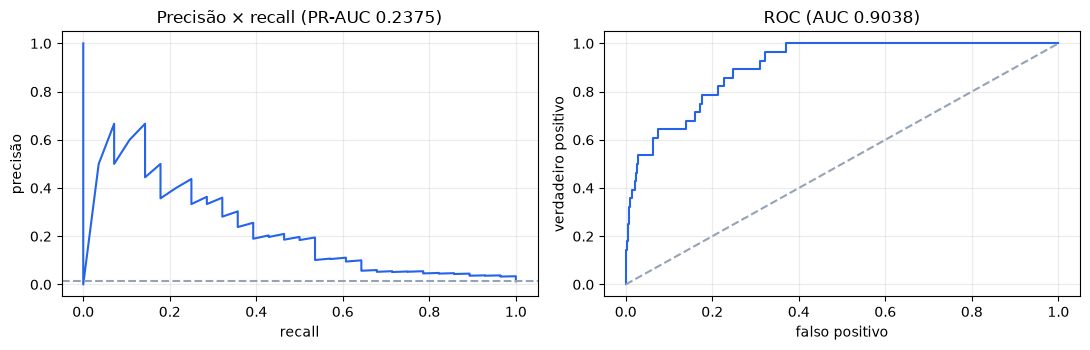

In [8]:
from sklearn.metrics import precision_recall_curve, roc_curve

artefato = registry.carregar('model_ola')
prob = artefato['modelo'].predict_proba(X_te[artefato['colunas']])[:, 1]
verdade = y[teste]

precisao, recall, _ = precision_recall_curve(verdade, prob)
fpr, tpr, _ = roc_curve(verdade, prob)

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.6))
a.plot(recall, precisao, color='#2563eb'); a.axhline(verdade.mean(), ls='--', color='#94a3b8')
a.set_xlabel('recall'); a.set_ylabel('precisão')
a.set_title(f'Precisão × recall (PR-AUC {cartao["metricas"]["teste"]["pr_auc"]})')
b.plot(fpr, tpr, color='#2563eb'); b.plot([0, 1], [0, 1], ls='--', color='#94a3b8')
b.set_xlabel('falso positivo'); b.set_ylabel('verdadeiro positivo')
b.set_title(f'ROC (AUC {cartao["metricas"]["teste"]["roc_auc"]})')
plt.tight_layout(); plt.show()

## Explicabilidade — quais fatores carregam o risco

In [9]:
pd.DataFrame(cartao['importancia_permutacao']).head(12)

,feature,descricao,queda_metrica,desvio
0,taxa_violacao_item,histórico de violação por item,0.30321,0.00241
1,minuto_do_dia,minuto do dia,0.17281,0.05665
2,hora,hora de abertura,0.14586,0.03538
3,taxa_violacao_equipe,histórico de violação da equipe,0.05889,0.02442
4,equipe_p2_media_7,média de incidentes P2 na semana — da equipe,0.04981,0.02769
5,aberto_manual,aberto manualmente (não por monitoramento),0.04894,0.03170
6,fora_horario,fora horario,0.03019,0.01899
7,fim_de_semana,é fim de semana,0.02598,0.01341
8,produto_media_7,média dos últimos 7 dias — do produto,0.01752,0.00773
9,dow,dia da semana previsto,0.01287,0.00374


In [10]:
print('Probabilidade média por equipe (usada na composição do risco diário):')
display(pd.Series(cartao['probabilidade_media']['equipe']).sort_values(ascending=False).head(8).round(4))

equipe = max(cartao['contribuicoes']['equipe'],
             key=lambda k: cartao['probabilidade_media']['equipe'].get(k, 0))
print(f'\nFatores que o modelo aponta para a equipe {equipe}:')
pd.DataFrame(cartao['contribuicoes']['equipe'][equipe])

Probabilidade média por equipe (usada na composição do risco diário):


Team07    0.3244
Team03    0.0378
Team08    0.0321
Team01    0.0226
Team11    0.0207
Team09    0.0193
Team02    0.0093
Team16    0.0091
dtype: float64


Fatores que o modelo aponta para a equipe Team07:


,feature,descricao,contribuicao,sentido
0,taxa_violacao_equipe,histórico de violação da equipe,2.7455,aumenta
1,taxa_violacao_item,histórico de violação por item,0.8840,aumenta
2,equipe_p2_media_7,média de incidentes P2 na semana — da equipe,0.7125,aumenta
3,taxa_violacao_produto,histórico de violação do produto,0.6192,aumenta
4,hora,hora de abertura,-0.4017,reduz


## Do incidente para o dia: como vira "risco de perder OLA amanhã"

O classificador estima a probabilidade de **um** incidente violar. O modelo de volume estima
**quantos** incidentes chegam amanhã. A chance de ao menos uma violação é a composição das duas
pontas — nenhuma delas arbitrada:

$$P(\text{ao menos 1 violação}) = 1 - (1 - p)^{\text{volume previsto}}$$

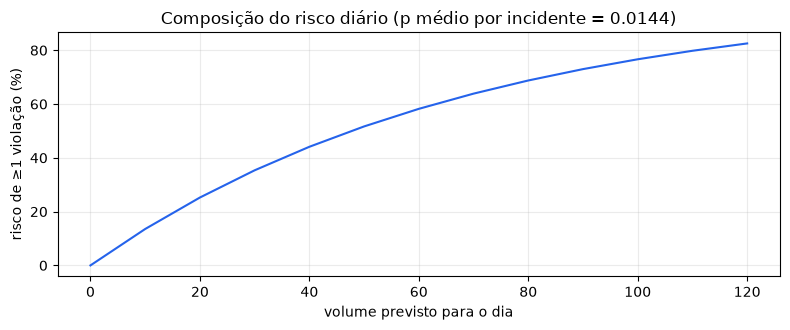

,volume,risco %
0,0,0.0
1,10,13.5
2,20,25.2
3,30,35.4
4,40,44.1
5,50,51.7
6,60,58.2
7,70,63.9


In [11]:
p = cartao['probabilidade_media']['global']
volumes = np.arange(0, 121, 10)
risco = 1 - (1 - p) ** volumes

fig, eixo = plt.subplots(figsize=(8, 3.4))
eixo.plot(volumes, risco * 100, color='#2563eb')
eixo.set_xlabel('volume previsto para o dia'); eixo.set_ylabel('risco de ≥1 violação (%)')
eixo.set_title(f'Composição do risco diário (p médio por incidente = {p:.4f})')
plt.tight_layout(); plt.show()
pd.DataFrame({'volume': volumes, 'risco %': (risco * 100).round(1)}).head(8)